In [2]:
import pandas as pd
import numpy as np 
df = pd.read_csv("students_feature_engineered_v2_large.csv")

np.random.seed(42)

flip_idx = np.random.choice(
    df.index,
    size=int(0.15 * len(df)),
    replace=False
)

df.loc[flip_idx, "Pass"] = 1 - df.loc[flip_idx, "Pass"]

df.to_csv(
    "students_feature_engineered_v2_large_noisy.csv",
    index=False
)


Bias-Variance Results
  max_depth  Mean Train Acc  Mean Test Acc  Std Test Acc  Gap (Train-Test)
0         1           0.593          0.593         0.002             0.000
1         2           0.630          0.566         0.022             0.064
2         3           0.661          0.597         0.016             0.064
3         4           0.692          0.592         0.015             0.100
4         5           0.728          0.588         0.012             0.140
5         6           0.766          0.571         0.021             0.195
6         8           0.846          0.573         0.024             0.273
7        10           0.909          0.560         0.031             0.349
8      None           1.000          0.540         0.027             0.460

Best Depth = 3
Best Validation Accuracy = 0.597


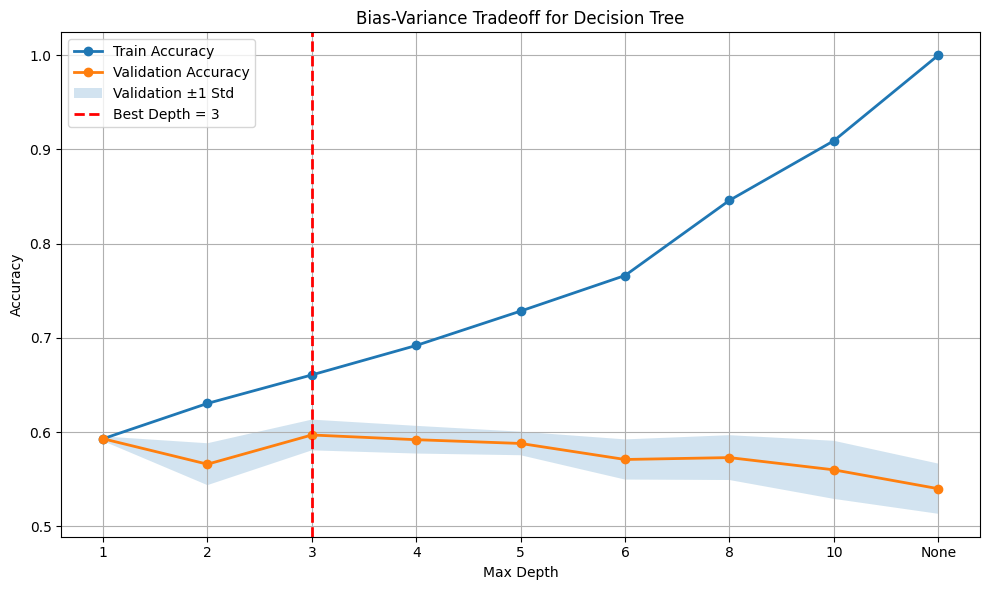

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("students_feature_engineered_v3.csv")

X = df.drop(columns=["Pass"])
y = df["Pass"]

depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
labels = [str(d) for d in depths]

tr_means = []
te_means = []
te_stds = []

for d in depths:

    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('clf', DecisionTreeClassifier(
            max_depth=d,
            random_state=42
        ))
    ])

    cv = cross_validate(
        pipe,
        X,
        y,
        cv=5,
        scoring='accuracy',
        return_train_score=True
    )

    tr_means.append(cv['train_score'].mean())
    te_means.append(cv['test_score'].mean())
    te_stds.append(cv['test_score'].std())


results = pd.DataFrame({
    'max_depth': labels,
    'Mean Train Acc': np.round(tr_means, 3),
    'Mean Test Acc': np.round(te_means, 3),
    'Std Test Acc': np.round(te_stds, 3)
})

results['Gap (Train-Test)'] = np.round(
    results['Mean Train Acc']
    - results['Mean Test Acc'],
    3
)

print("\nBias-Variance Results")
print(results)


best_idx = np.argmax(te_means)
best_depth = labels[best_idx]

print(f"\nBest Depth = {best_depth}")
print(f"Best Validation Accuracy = {te_means[best_idx]:.3f}")


x = np.arange(len(depths))

tr_means = np.array(tr_means)
te_means = np.array(te_means)
te_stds = np.array(te_stds)

plt.figure(figsize=(10, 6))

# Training Accuracy
plt.plot(
    x,
    tr_means,
    marker='o',
    linewidth=2,
    label='Train Accuracy'
)

# Validation Accuracy
plt.plot(
    x,
    te_means,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

# Error Band
plt.fill_between(
    x,
    te_means - te_stds,
    te_means + te_stds,
    alpha=0.2,
    label='Validation ±1 Std'
)

# Vertical line for best depth
plt.axvline(
    x=best_idx,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Best Depth = {best_depth}'
)

plt.xticks(x, labels)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff for Decision Tree')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('bias_variance_curve.png')
plt.show()

In [4]:
# 1)At which depth does overfitting clearly begin? How can you tell from the curves?

# Overfitting begins around max_depth = 5. Up to depth 3, the validation accuracy improves slightly while the training and validation curves remain relatively close. Beyond depth 5, the training accuracy continues to increase rapidly,
# but the validation accuracy starts decreasing and the gap between the two curves widens. This indicates that the model is memorising the training data rather than learning patterns that generalise to unseen data.


# 2)What happens to variance (std_test) as depth increases? Why?
# As the tree depth increases, the standard deviation of the validation accuracy generally becomes larger. Deep trees are highly sensitive to
# the specific samples present in each training fold, so different folds can produce noticeable accuracies.
# This increased sensitivity causes higher variance and makes the model less stable across different data splits.




In [5]:
# #ts7
# Optimism Bias

# You become overly optimistic because you selected the model that happened to do best on your validation folds.

#nested CV---only when no split and small dataset

In [6]:
#nested CV did not get why we require
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from collections import Counter



outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=0
)


param_grid = {
    'clf__max_depth': [2, 3, 4, 5],
    'clf__min_samples_split': [2, 5, 10]
}

outer_scores = []
best_params_list = []


for fold, (tr_idx, te_idx) in enumerate(
        outer_cv.split(X, y), start=1):

    X_tr = X.values[tr_idx]
    X_te = X.values[te_idx]

    y_tr = y.values[tr_idx]
    y_te = y.values[te_idx]

    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('clf',
         DecisionTreeClassifier(
             random_state=42
         ))
    ])


    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_tr, y_tr)


    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_te)

    acc = accuracy_score(
        y_te,
        y_pred
    )

    outer_scores.append(acc)
    best_params_list.append(
        grid.best_params_
    )

    print(f"\nFold {fold}")
    print(
        f"Accuracy : {acc:.3f}"
    )
    print(
        f"Best Params : {grid.best_params_}"
    )


print("\n" + "="*50)
print("NESTED CV RESULTS")
print("="*50)

print(
    f"Scores : "
    f"{np.round(outer_scores,3)}"
)

print(
    f"Mean Accuracy : "
    f"{np.mean(outer_scores):.3f}"
)

print(
    f"Std Accuracy : "
    f"{np.std(outer_scores):.3f}"
)


params_counter = Counter(
    tuple(sorted(d.items()))
    for d in best_params_list
)

print("\nMost Frequent Hyperparameters:")

for params, count in params_counter.items():

    print(
        dict(params),
        f"-> selected {count} times"
    )


Fold 1
Accuracy : 0.560
Best Params : {'clf__max_depth': 2, 'clf__min_samples_split': 2}

Fold 2
Accuracy : 0.590
Best Params : {'clf__max_depth': 3, 'clf__min_samples_split': 2}

Fold 3
Accuracy : 0.590
Best Params : {'clf__max_depth': 5, 'clf__min_samples_split': 10}

Fold 4
Accuracy : 0.605
Best Params : {'clf__max_depth': 4, 'clf__min_samples_split': 5}

Fold 5
Accuracy : 0.555
Best Params : {'clf__max_depth': 3, 'clf__min_samples_split': 2}

NESTED CV RESULTS
Scores : [0.56  0.59  0.59  0.605 0.555]
Mean Accuracy : 0.580
Std Accuracy : 0.019

Most Frequent Hyperparameters:
{'clf__max_depth': 2, 'clf__min_samples_split': 2} -> selected 1 times
{'clf__max_depth': 3, 'clf__min_samples_split': 2} -> selected 2 times
{'clf__max_depth': 5, 'clf__min_samples_split': 10} -> selected 1 times
{'clf__max_depth': 4, 'clf__min_samples_split': 5} -> selected 1 times


In [7]:
# Why does non-nested CV systematically overestimate generalisation performance?

# Non-nested cross-validation uses the same data both to select the best hyperparameters and to estimate the model's performance. Since the model is 
# chosen because it performed best on those validation folds, the resulting score is slightly optimistic and tends to overestimate true generalisation performance. 
# Nested cross-validation avoids this by using a separate outer test fold that never participates in model selection.

# 2)What does optimism bias mean in practice when you deploy a model?
# Optimism bias means that the reported validation accuracy is higher than the model's true performance on new, unseen data. In practice, a model that appears highly
# accurate during development may perform worse after deployment because its reported score was influenced by the hyperparameter tuning process.


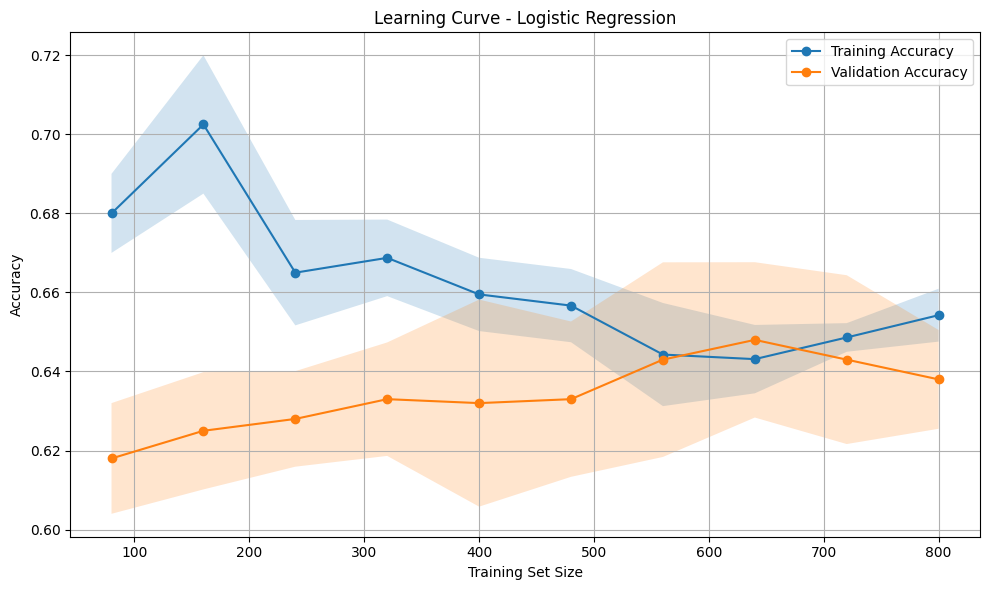

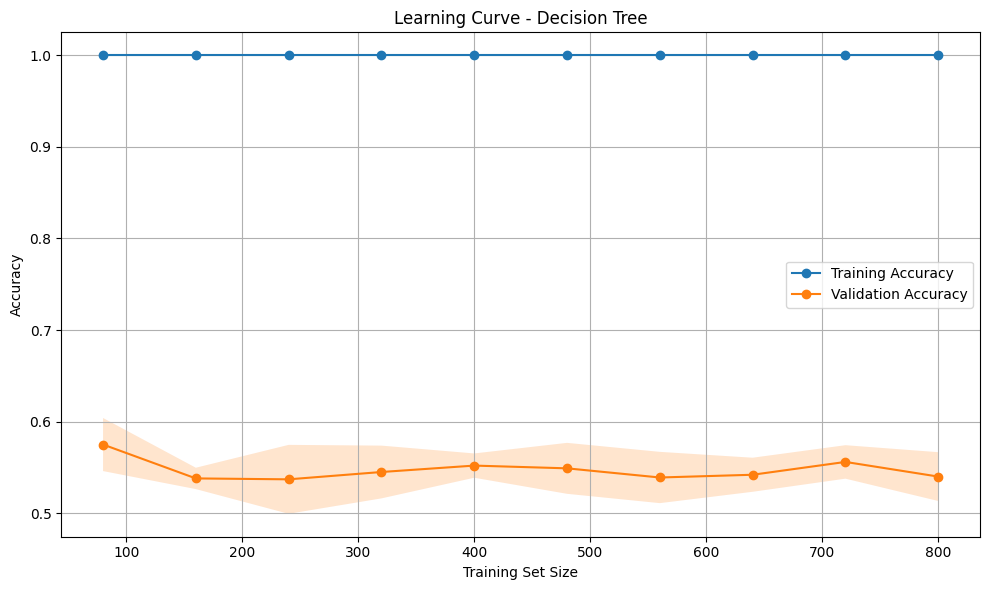


Logistic Regression
Final Train Accuracy : 0.654
Final Validation Accuracy : 0.638

Decision Tree
Final Train Accuracy : 1.000
Final Validation Accuracy : 0.540


In [8]:
#task 8
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


pipe_lr = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500))
])

train_sizes_lr, tr_scores_lr, val_scores_lr = learning_curve(
    pipe_lr,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    return_times=False
)

tr_mean_lr = tr_scores_lr.mean(axis=1)
tr_std_lr = tr_scores_lr.std(axis=1)

val_mean_lr = val_scores_lr.mean(axis=1)
val_std_lr = val_scores_lr.std(axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes_lr,
    tr_mean_lr,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes_lr,
    val_mean_lr,
    marker='o',
    label='Validation Accuracy'
)

plt.fill_between(
    train_sizes_lr,
    tr_mean_lr - tr_std_lr,
    tr_mean_lr + tr_std_lr,
    alpha=0.2
)

plt.fill_between(
    train_sizes_lr,
    val_mean_lr - val_std_lr,
    val_mean_lr + val_std_lr,
    alpha=0.2
)

plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Logistic Regression')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('learning_curve_lr.png')
plt.show()


pipe_dt = Pipeline([
    ('sc', StandardScaler()),
    ('clf', DecisionTreeClassifier(
        max_depth=None,
        random_state=42
    ))
])

train_sizes_dt, tr_scores_dt, val_scores_dt = learning_curve(
    pipe_dt,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    return_times=False
)

tr_mean_dt = tr_scores_dt.mean(axis=1)
tr_std_dt = tr_scores_dt.std(axis=1)

val_mean_dt = val_scores_dt.mean(axis=1)
val_std_dt = val_scores_dt.std(axis=1)


plt.figure(figsize=(10,6))

plt.plot(
    train_sizes_dt,
    tr_mean_dt,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes_dt,
    val_mean_dt,
    marker='o',
    label='Validation Accuracy'
)

plt.fill_between(
    train_sizes_dt,
    tr_mean_dt - tr_std_dt,
    tr_mean_dt + tr_std_dt,
    alpha=0.2
)

plt.fill_between(
    train_sizes_dt,
    val_mean_dt - val_std_dt,
    val_mean_dt + val_std_dt,
    alpha=0.2
)

plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Decision Tree')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('learning_curve_dt.png')
plt.show()


print("\nLogistic Regression")
print(f"Final Train Accuracy : {tr_mean_lr[-1]:.3f}")
print(f"Final Validation Accuracy : {val_mean_lr[-1]:.3f}")

print("\nDecision Tree")
print(f"Final Train Accuracy : {tr_mean_dt[-1]:.3f}")
print(f"Final Validation Accuracy : {val_mean_dt[-1]:.3f}")

In [9]:
# For LogisticRegression: do train and val curves converge? What does that tell you?
# Yes, the training and validation curves converge and become very close as the training size increases. Both curves intersect at a relatively low accuracy of 
# around 64%, indicating that the model suffers from high bias (underfitting). Since the curves have already converged, adding more data is unlikely to improve
# performance significantly. Better results would require a more expressive model or additional feature engineering.


# For the full Decision Tree: what shape do the curves take and what remedies would you apply?
# The full Decision Tree shows a high-variance learning curve. The training accuracy remains at 100% for all training sizes, while the validation accuracy 
# stays much lower at around 54%, producing a large and persistent gap between the curves. This indicates severe overfitting, where the model memorises the training
# data but generalises poorly to unseen samples. Possible remedies include reducing the tree depth, increasing min_samples_split or min_samples_leaf, applying pruning,
# using ensemble methods such as Random Forests, or collecting more training data.

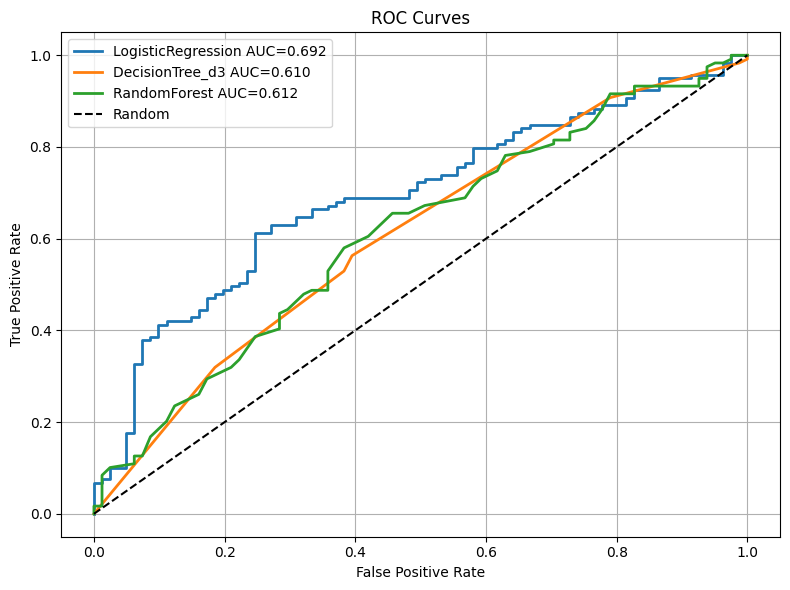

                Model  Accuracy       AUC  Best Threshold  Rank by AUC
0  LogisticRegression     0.635  0.691566        0.636163            1
2        RandomForest     0.615  0.611785        0.580000            2
1     DecisionTree_d3     0.625  0.609555        0.555556            3


In [10]:
#tsk 9
# AUC is considered threshold-independent because it evaluates the model's ability to rank positive samples above negative samples across all possible classification
# thresholds rather than at a single fixed threshold such as 0.5.

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    accuracy_score
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


classifiers = {
    'LogisticRegression':
        LogisticRegression(max_iter=500),

    'DecisionTree_d3':
        DecisionTreeClassifier(
            max_depth=3,
            random_state=42
        ),

    'RandomForest':
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}


results = []

fig, ax = plt.subplots(figsize=(8,6))

for name, clf in classifiers.items():

    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('clf', clf)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    proba = pipe.predict_proba(X_test)[:,1]

    acc = accuracy_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        proba
    )

    fpr, tpr, thresholds = roc_curve(
        y_test,
        proba
    )



    J = tpr - fpr
    best_idx = np.argmax(J)
    best_threshold = thresholds[best_idx]

    results.append([
        name,
        acc,
        auc,
        best_threshold
    ])

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} AUC={auc:.3f}'
    )

# Random classifier line
ax.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random'
)

ax.set_xlabel(
    'False Positive Rate'
)

ax.set_ylabel(
    'True Positive Rate'
)

ax.set_title(
    'ROC Curves'
)

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(
    'roc_curves.png'
)
plt.show()

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'AUC',
        'Best Threshold'
    ]
)

results_df['Rank by AUC'] = (
    results_df['AUC']
    .rank(ascending=False)
    .astype(int)
)

print(results_df.sort_values(
    'AUC',
    ascending=False
))

In [11]:
# 1)A model has accuracy = 0.90 but AUC = 0.61. What does this imply?
# A high accuracy of 90% combined with an AUC of only 0.61 suggests that the dataset is likely imbalanced and the model has poor discriminative ability. 
# The model correctly predicts the majority class most of the time, which inflates the accuracy, but it is not effective at ranking positive and negative samples. 
# Therefore, the model may perform poorly on the minority class despite its high accuracy.

# 2)How would you select the optimal probability threshold for a medical screening scenario where false negatives are far more costly than false positives?
# In a medical screening application, missing a true positive case can have serious consequences. Therefore, the probability threshold should be lowered to
# increase sensitivity and reduce false negatives, even if this leads to more false positives. The threshold should be selected by prioritising a high true positive
# rate rather than simply maximising overall accuracy.


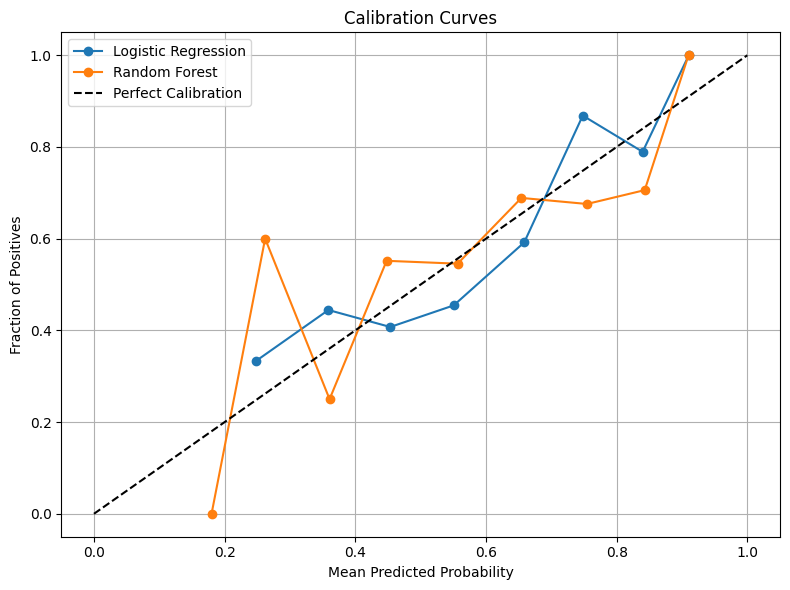

Brier Scores
Logistic Regression : 0.2173
Random Forest : 0.2369


c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


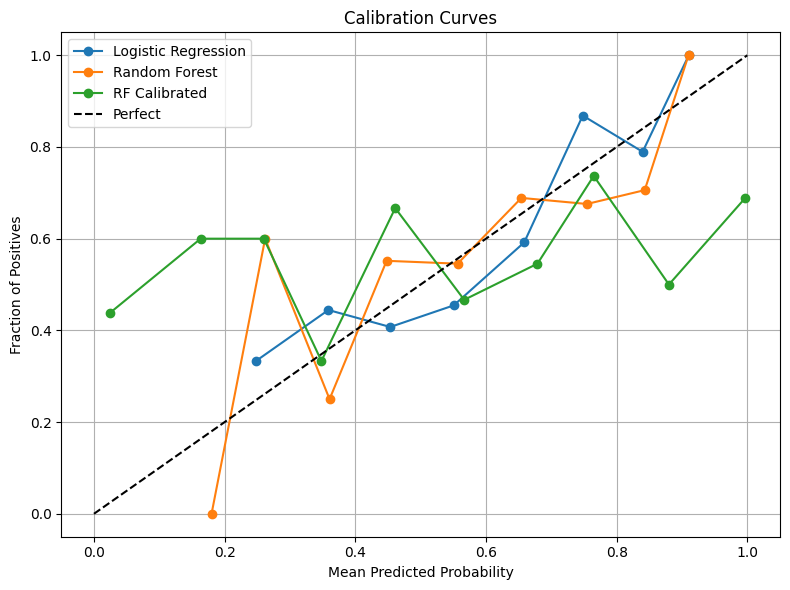

   Threshold  Precision  Recall     F1
0        0.1      0.595   1.000  0.746
1        0.2      0.598   1.000  0.748
2        0.3      0.598   0.950  0.734
3        0.4      0.619   0.916  0.739
4        0.5      0.646   0.782  0.707
5        0.6      0.679   0.605  0.640
6        0.7      0.691   0.319  0.437
7        0.8      0.750   0.126  0.216
8        0.9      1.000   0.017  0.033


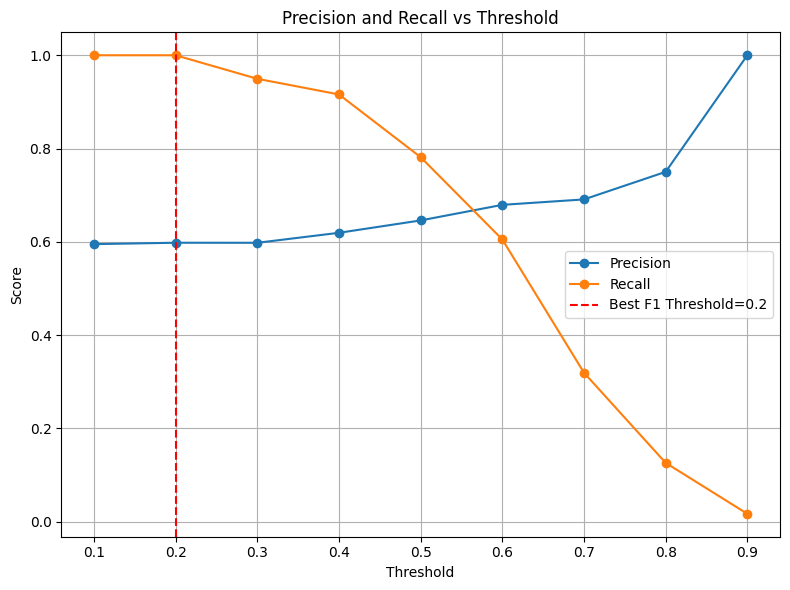

Best F1 Threshold = 0.2


In [12]:
#tsk 10
from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500))
])

rf_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('clf',
     RandomForestClassifier(
         n_estimators=100,
         random_state=42
     ))
])

lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

proba_lr = lr_pipe.predict_proba(X_test)[:,1]
proba_rf = rf_pipe.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,6))

for name, proba in [
    ('Logistic Regression', proba_lr),
    ('Random Forest', proba_rf)
]:

    frac_pos, mean_pred = calibration_curve(
        y_test,
        proba,
        n_bins=10
    )

    plt.plot(
        mean_pred,
        frac_pos,
        marker='o',
        label=name
    )

plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Perfect Calibration'
)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    'calibration_curves.png'
)
plt.show()

brier_lr = brier_score_loss(
    y_test,
    proba_lr
)

brier_rf = brier_score_loss(
    y_test,
    proba_rf
)

print("Brier Scores")
print(
    f"Logistic Regression : {brier_lr:.4f}"
)
print(
    f"Random Forest : {brier_rf:.4f}"
)

calib_rf = CalibratedClassifierCV(
    rf_pipe,
    cv='prefit',
    method='isotonic'
)

calib_rf.fit(X_train, y_train)

proba_rf_cal = (
    calib_rf
    .predict_proba(X_test)[:,1]
)

frac_pos, mean_pred = calibration_curve(
    y_test,
    proba_rf_cal,
    n_bins=10
)

plt.figure(figsize=(8,6))

for name, proba in [
    ('Logistic Regression', proba_lr),
    ('Random Forest', proba_rf),
    ('RF Calibrated', proba_rf_cal)
]:

    frac_pos, mean_pred = calibration_curve(
        y_test,
        proba,
        n_bins=10
    )

    plt.plot(
        mean_pred,
        frac_pos,
        marker='o',
        label=name
    )

plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Perfect'
)

plt.xlabel(
    'Mean Predicted Probability'
)

plt.ylabel(
    'Fraction of Positives'
)

plt.title(
    'Calibration Curves'
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    'calibration_curves.png'
)
plt.show()

records = []

for thr in np.arange(0.1, 1.0, 0.1):

    preds = (
        proba_rf >= thr
    ).astype(int)

    precision = precision_score(
        y_test,
        preds,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        preds,
        zero_division=0
    )

    records.append({
        'Threshold': round(thr,1),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_df = pd.DataFrame(
    records
)

print(
    threshold_df.round(3)
)

best_idx = threshold_df['F1'].idxmax()

best_thr = threshold_df.loc[
    best_idx,
    'Threshold'
]

plt.figure(figsize=(8,6))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.axvline(
    best_thr,
    color='red',
    linestyle='--',
    label=f'Best F1 Threshold={best_thr}'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    'threshold_sweep.png'
)
plt.show()

print(
    f"Best F1 Threshold = {best_thr}"
)

In [13]:
#1) Which model was better calibrated before isotonic correction, and how can you tell?
# Logistic Regression was better calibrated before isotonic correction. Its reliability curve lies closer to the diagonal line representing perfect calibration, 
# and it also achieves a lower Brier score (0.2173 versus 0.2369 for Random Forest). This indicates that the predicted probabilities from Logistic Regression more
# accurately reflect the true frequencies of the positive class.


#2) In a fraud-detection context (rare positive class), would you raise or lower the default 0.5 threshold? Use the threshold sweep results to justify your answer.
# In a fraud-detection system, the default threshold of 0.5 should generally be lowered because missing fraudulent transactions is more costly than investigating additional
# false alarms. The threshold sweep shows that lower thresholds such as 0.2 achieve very high recall (1.0), ensuring that nearly all fraud cases are detected. Although 
# precision decreases slightly, this trade-off is often acceptable because false positives can be manually reviewed, whereas missed fraud can result in significant financial losses.


Baseline Accuracy: 0.615
                         mean     std
Assignments_Completed  0.0395  0.0213
Sleep_Hours            0.0287  0.0173
Study_Hours            0.0173  0.0168
Stress_Level           0.0125  0.0202
Days_Absent            0.0117  0.0148
Attendance             0.0035  0.0174
Previous_Grade         0.0002  0.0152
Extracurricular_Hours -0.0017  0.0127
                         mean     std  Significant?
Assignments_Completed  0.0395  0.0213          True
Sleep_Hours            0.0287  0.0173          True
Study_Hours            0.0173  0.0168          True
Stress_Level           0.0125  0.0202         False
Days_Absent            0.0117  0.0148         False
Attendance             0.0035  0.0174         False
Previous_Grade         0.0002  0.0152         False
Extracurricular_Hours -0.0017  0.0127         False


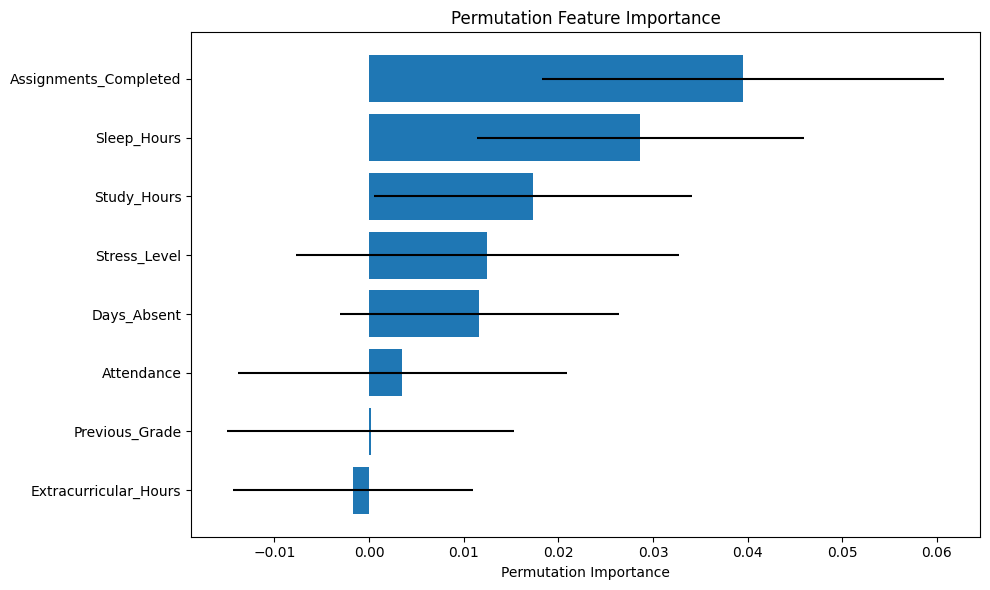

Top 5 Features:
['Assignments_Completed', 'Sleep_Hours', 'Study_Hours', 'Stress_Level', 'Days_Absent']
Top-5 Accuracy: 0.620
    Features Used  n_features  Test Accuracy  Δ vs Full Model
0    All Features           8          0.615            0.000
1  Top 5 Features           5          0.620            0.005


In [14]:
#hw1
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

rf_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipe.fit(X_train, y_train)

baseline_acc = rf_pipe.score(X_test, y_test)

print(f"Baseline Accuracy: {baseline_acc:.3f}")

result = permutation_importance(
    rf_pipe,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42
)

perm_df = pd.DataFrame(
    result.importances.T,
    columns=X.columns
)

summary = (
    perm_df
    .agg(['mean', 'std'])
    .T
    .sort_values(
        'mean',
        ascending=False
    )
)

print(summary.round(4))

summary['Significant?'] = (
    summary['mean']
    > summary['std']
)

print(summary.round(4))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    summary.index,
    summary['mean'],
    xerr=summary['std']
)

plt.xlabel('Permutation Importance')
plt.title('Permutation Feature Importance')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(
    'permutation_importance.png'
)

plt.show()

top5_features = (
    summary
    .head(5)
    .index
    .tolist()
)

print("Top 5 Features:")
print(top5_features)

X_train_top5 = X_train[top5_features]
X_test_top5 = X_test[top5_features]

rf_top5 = Pipeline([
    ('sc', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_top5.fit(
    X_train_top5,
    y_train
)

top5_acc = rf_top5.score(
    X_test_top5,
    y_test
)

print(
    f"Top-5 Accuracy: {top5_acc:.3f}"
)

comparison = pd.DataFrame({
    'Features Used': [
        'All Features',
        'Top 5 Features'
    ],
    'n_features': [
        X.shape[1],
        5
    ],
    'Test Accuracy': [
        baseline_acc,
        top5_acc
    ]
})

comparison['Δ vs Full Model'] = (
    comparison['Test Accuracy']
    - baseline_acc
)

print(comparison.round(3))

In [ ]:
# What does a negative permutation importance value mean? Should you remove that feature?
# A negative permutation importance means that the model's accuracy slightly improved after the feature was randomly shuffled. This usually indicates that the feature 
# contributes little useful information and may simply introduce noise. However, a negative value is often caused by random variation, especially when the standard 
# deviation is large, so the feature should not automatically be removed without further investigation.


SKFold-5: mean=0.603 std=0.031 n=5
RepSKFold-5x10: mean=0.613 std=0.026 n=50
RepSKFold-5x30: mean=0.609 std=0.029 n=150
         Protocol  n_scores  Mean Accuracy     Std  95% CI width
0        SKFold-5         5         0.6030  0.0311        0.0272
1  RepSKFold-5x10        50         0.6132  0.0258        0.0072
2  RepSKFold-5x30       150         0.6085  0.0287        0.0046


C:\Users\heerm\AppData\Local\Temp\ipykernel_19652\3226156871.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


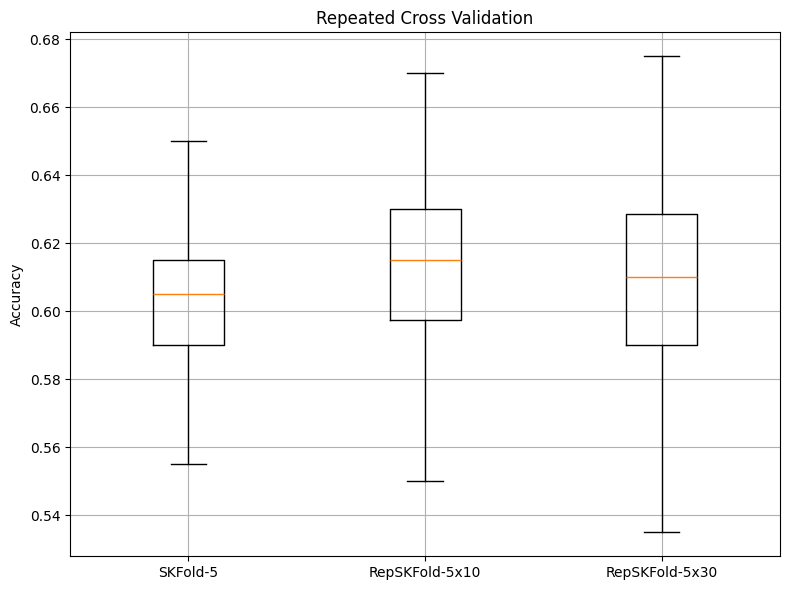

T-statistic = -0.4171
P-value = 0.6772


In [15]:
# hw7
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score
)

from scipy import stats

pipe = Pipeline([
    ('sc', StandardScaler()),
    ('clf',
     DecisionTreeClassifier(
         max_depth=3,
         random_state=42
     ))
])

protocols = {
    'SKFold-5':
        StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        ),

    'RepSKFold-5x10':
        RepeatedStratifiedKFold(
            n_splits=5,
            n_repeats=10,
            random_state=42
        ),

    'RepSKFold-5x30':
        RepeatedStratifiedKFold(
            n_splits=5,
            n_repeats=30,
            random_state=42
        )
}

results = {}

for name, cv_obj in protocols.items():

    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=cv_obj,
        scoring='accuracy'
    )

    results[name] = scores

    print(
        f"{name}: "
        f"mean={scores.mean():.3f} "
        f"std={scores.std():.3f} "
        f"n={len(scores)}"
    )

    summary = []

for name, scores in results.items():

    mean = scores.mean()
    std = scores.std()
    n = len(scores)

    ci_width = (
        1.96
        * std
        / np.sqrt(n)
    )

    summary.append([
        name,
        n,
        mean,
        std,
        ci_width
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        'Protocol',
        'n_scores',
        'Mean Accuracy',
        'Std',
        '95% CI width'
    ]
)

print(summary_df.round(4))

plt.figure(figsize=(8,6))

plt.boxplot(
    list(results.values()),
    labels=list(results.keys())
)

plt.ylabel('Accuracy')
plt.title(
    'Repeated Cross Validation'
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    'repeated_cv_boxplot.png'
)

plt.show()

t_stat, p_val = stats.ttest_ind(
    results['SKFold-5'],
    results['RepSKFold-5x30']
)

print(
    f"T-statistic = {t_stat:.4f}"
)

print(
    f"P-value = {p_val:.4f}"
)

In [ ]:
# Why does increasing n_repeats reduce the std of the score estimate? Is the mean also expected to change substantially?
# Increasing the number of repeats averages the model's performance over many different train-test splits, reducing the influence of any particular lucky or
# unlucky partition of the data. As a result, the estimate becomes more stable and the standard deviation generally decreases. However, the mean accuracy is usually
# not expected to change substantially because the underlying model and dataset remain the same.


# What is the practical cost of using 30 repeats instead of 1? In what scenario would 30 repeats be worth it?
# Using 30 repeats significantly increases computational cost because the model must be trained and evaluated many more times. A 5-fold repeated cross-validation 
# with 30 repeats requires 150 model fits compared with only 5 fits for a single 5-fold cross-validation. This additional cost is worthwhile for small datasets, research 
# studies, or situations where highly reliable performance estimates are required.


# The t-test produced a p-value of 0.6772, which is much greater than the significance level of 0.05. Therefore, there is no statistically
# significant difference between the mean accuracies obtained using a single Stratified K-Fold and a 30-repeat Repeated Stratified K-Fold. Repeated cross-validation
# improves the stability of the estimate but does not substantially change the model's average performance.

In [16]:
from sklearn.metrics import (
    make_scorer,
    confusion_matrix
)

FN_COST = 5
FP_COST = 1


def cost_score(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    total_cost = (
        FN_COST * fn
        + FP_COST * fp
    )

    return -total_cost

cost_scorer = make_scorer(
    cost_score
)

param_grid = {
    'clf__max_depth': [2,3,4,5],
    'clf__min_samples_split': [2,5,10]
}

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('sc', StandardScaler()),
    ('clf',
     DecisionTreeClassifier(
         random_state=42
     ))
])

grid_cost = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring=cost_scorer,
    n_jobs=-1
)

grid_cost.fit(
    X_train,
    y_train
)

print(
    "Best Params (Cost):"
)
print(
    grid_cost.best_params_
)

print(
    "Best Cost Score:"
)
print(
    grid_cost.best_score_
)

grid_acc = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_acc.fit(
    X_train,
    y_train
)

print(
    "Best Params (Accuracy):"
)
print(
    grid_acc.best_params_
)

print(
    "Best Accuracy:"
)
print(
    grid_acc.best_score_
)


from sklearn.metrics import accuracy_score

best_cost_model = (
    grid_cost.best_estimator_
)

y_pred = best_cost_model.predict(
    X_test
)

acc = accuracy_score(
    y_test,
    y_pred
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

test_cost = (
    FN_COST * fn
    + FP_COST * fp
)

print(
    f"Test Accuracy: {acc:.3f}"
)

print(
    f"Test Cost: {test_cost}"
)

proba = (
    best_cost_model
    .predict_proba(X_test)[:,1]
)

records = []

for thr in [
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8
]:

    preds = (
        proba >= thr
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        preds
    ).ravel()

    total_cost = (
        FN_COST * fn
        + FP_COST * fp
    )

    records.append({
        'Threshold': thr,
        'FP': fp,
        'FN': fn,
        'Total Cost': total_cost
    })

threshold_df = pd.DataFrame(
    records
)

print(threshold_df)

best_idx = (
    threshold_df[
        'Total Cost'
    ].idxmin()
)

print(
    threshold_df.loc[
        best_idx
    ]
)

Best Params (Cost):
{'clf__max_depth': 3, 'clf__min_samples_split': 2}
Best Cost Score:
-137.8
Best Params (Accuracy):
{'clf__max_depth': 3, 'clf__min_samples_split': 2}
Best Accuracy:
0.60375
Test Accuracy: 0.625
Test Cost: 119
   Threshold  FP  FN  Total Cost
0        0.2  80   2          90
1        0.3  80   2          90
2        0.4  64  11         119
3        0.5  64  11         119
4        0.6  31  56         311
5        0.7  15  81         420
6        0.8  15  81         420
Threshold      0.2
FP            80.0
FN             2.0
Total Cost    90.0
Name: 0, dtype: float64


In [ ]:
# Why do accuracy-optimal hyperparameters sometimes differ from cost-optimal ones?

# Accuracy treats all mistakes equally, whereas cost-sensitive learning assigns different penalties to different types of errors. A model that achieves the 
# highest accuracy may still produce many expensive false negatives, making it undesirable in practice. Cost-optimised hyperparameters therefore focus on minimising
#  the total business cost rather than maximising the number of correct predictions.


# if FN_COST increases from 5 to 20, what happens to the threshold?
#If the false negative cost increases from 5 to 20, the optimal threshold would move lower than 0.5. Lowering the threshold causes the model to predict the
#positive class more frequently, which reduces the number of false negatives. Although this may increase false positives, the trade-off is worthwhile because 
# false negatives are now much more expensive.


(569, 30)
1    357
0    212
Name: count, dtype: int64
Baseline Accuracy: 0.980 ± 0.013
Train Accuracy : 1.000
Validation Accuracy : 0.910
Gap : 0.090


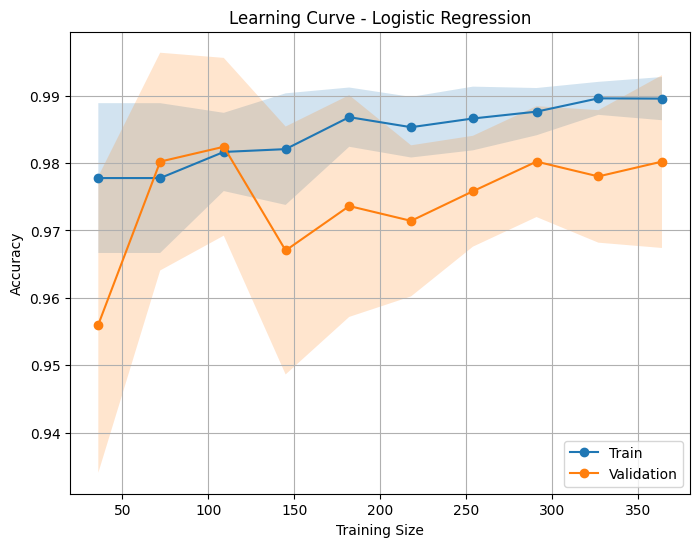

Best Tree Params:
{'clf__criterion': 'entropy', 'clf__max_depth': 2, 'clf__min_samples_split': 2}
Best Tree CV AUC: 0.951
Best RF Params:
{'clf__n_estimators': np.int64(225), 'clf__min_samples_split': 2, 'clf__max_features': 'log2', 'clf__max_depth': 5}
Best RF CV AUC: 0.991


In [17]:
#hw9
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    learning_curve,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay,
    brier_score_loss
)

from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

bc = load_breast_cancer()

X = pd.DataFrame(
    bc.data,
    columns=bc.feature_names
)

y = pd.Series(
    bc.target
)

print(X.shape)
print(y.value_counts())



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

pipe_lr = Pipeline([
    ('sc', StandardScaler()),
    ('clf',
     LogisticRegression(
         max_iter=2000
     ))
])

scores = cross_val_score(
    pipe_lr,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(
    f"Baseline Accuracy: "
    f"{scores.mean():.3f} ± {scores.std():.3f}"
)

tree_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('clf',
     DecisionTreeClassifier(
         max_depth=None,
         random_state=42
     ))
])

cv_tree = cross_validate(
    tree_pipe,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

train_acc = (
    cv_tree['train_score']
    .mean()
)

test_acc = (
    cv_tree['test_score']
    .mean()
)

gap = train_acc - test_acc

print(
    f"Train Accuracy : {train_acc:.3f}"
)

print(
    f"Validation Accuracy : {test_acc:.3f}"
)

print(
    f"Gap : {gap:.3f}"
)

train_sizes, tr_scores, val_scores = learning_curve(
    pipe_lr,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    )
)

tr_mean = tr_scores.mean(axis=1)
tr_std = tr_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    tr_mean,
    marker='o',
    label='Train'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation'
)

plt.fill_between(
    train_sizes,
    tr_mean-tr_std,
    tr_mean+tr_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.2
)

plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Logistic Regression')
plt.legend()
plt.grid()

plt.savefig(
    'bc_learning_curve.png'
)

plt.show()

tree_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('clf',
     DecisionTreeClassifier(
         random_state=42
     ))
])

param_grid = {
    'clf__max_depth':
        [2,3,4,5,6],

    'clf__min_samples_split':
        [2,5,10],

    'clf__criterion':
        ['gini','entropy']
}

grid_tree = GridSearchCV(
    tree_pipe,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_tree.fit(
    X_train,
    y_train
)

print(
    "Best Tree Params:"
)

print(
    grid_tree.best_params_
)

print(
    f"Best Tree CV AUC: "
    f"{grid_tree.best_score_:.3f}"
)

rf_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('clf',
     RandomForestClassifier(
         random_state=42
     ))
])

param_dist = {
    'clf__n_estimators':
        np.arange(50,301,25),

    'clf__max_depth':
        [None,2,3,4,5,6,8,10],

    'clf__min_samples_split':
        [2,5,10],

    'clf__max_features':
        ['sqrt','log2']
}

random_rf = RandomizedSearchCV(
    rf_pipe,
    param_dist,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(
    X_train,
    y_train
)

print(
    "Best RF Params:"
)

print(
    random_rf.best_params_
)

print(
    f"Best RF CV AUC: "
    f"{random_rf.best_score_:.3f}"
)

Test Accuracy: 0.956
Test AUC: 0.992
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

[[39  3]
 [ 2 70]]


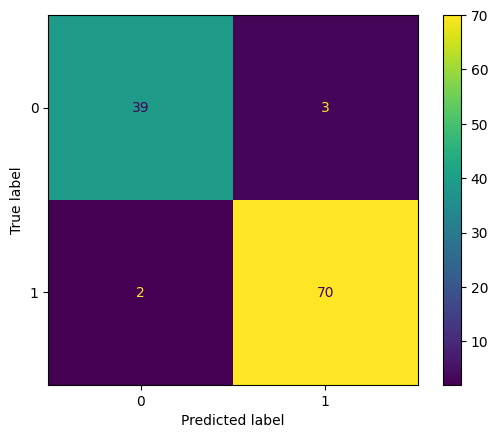

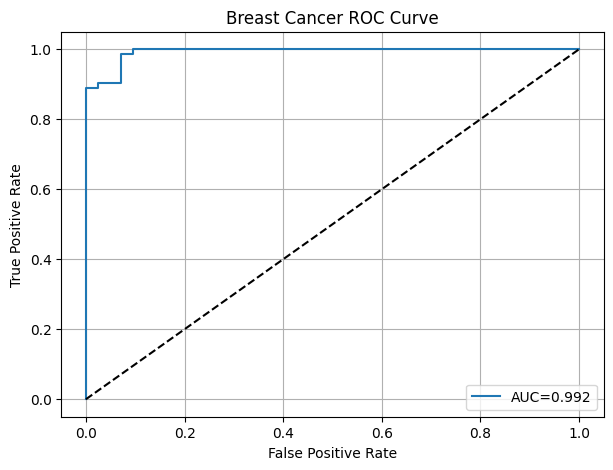

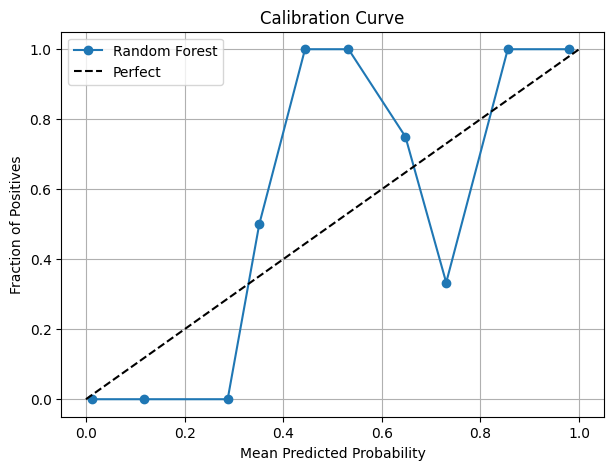

                 Feature  Importance       Std
23            worst area    0.011111  0.010846
27  worst concave points    0.008772  0.005992
0            mean radius    0.007895  0.002632
21         worst texture    0.007602  0.006298
2         mean perimeter    0.007018  0.003509
4        mean smoothness    0.006725  0.003710
15     compactness error    0.005556  0.004227
7    mean concave points    0.004971  0.004347
22       worst perimeter    0.004971  0.006674
24      worst smoothness    0.003801  0.004347


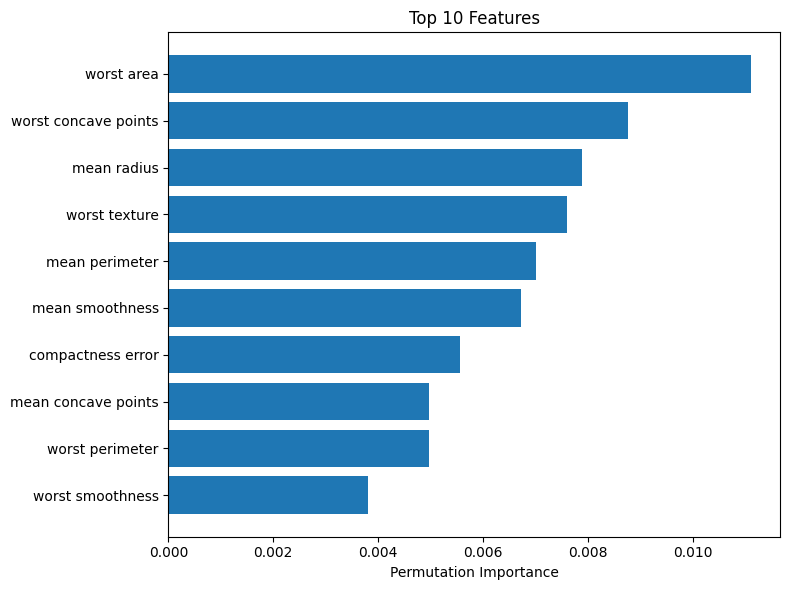

Misclassified: 5
Percentage: 4.39%


In [18]:
best_model = random_rf.best_estimator_

y_pred = best_model.predict(X_test)

y_proba = (
    best_model
    .predict_proba(X_test)[:,1]
)

acc = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Test Accuracy: {acc:.3f}"
)


auc = roc_auc_score(
    y_test,
    y_proba
)

print(
    f"Test AUC: {auc:.3f}"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

ConfusionMatrixDisplay(
    cm
).plot()

plt.show()

fpr, tpr, _ = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC={auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'Breast Cancer ROC Curve'
)

plt.legend()

plt.grid()

plt.savefig(
    'bc_roc_curve.png'
)

plt.show()

frac_pos, mean_pred = calibration_curve(
    y_test,
    y_proba,
    n_bins=10
)

plt.figure(figsize=(7,5))

plt.plot(
    mean_pred,
    frac_pos,
    marker='o',
    label='Random Forest'
)

plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Perfect'
)

plt.xlabel(
    'Mean Predicted Probability'
)

plt.ylabel(
    'Fraction of Positives'
)

plt.title(
    'Calibration Curve'
)

plt.legend()

plt.grid()

plt.savefig(
    'bc_calibration.png'
)

plt.show()

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
        result.importances_mean,
    'Std':
        result.importances_std
})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

print(
    importance_df.head(10)
)

top10 = (
    importance_df
    .head(10)
)

plt.figure(figsize=(8,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel(
    'Permutation Importance'
)

plt.title(
    'Top 10 Features'
)

plt.tight_layout()

plt.savefig(
    'bc_perm_importance.png'
)

plt.show()

results = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'y_proba': y_proba
})

results['correct'] = (
    results.y_true
    == results.y_pred
).astype(int)

results.to_csv(
    'bc_predictions.csv',
    index=False
)

misclassified = (
    results['correct']
    == 0
).sum()

pct = (
    misclassified
    / len(results)
    * 100
)

print(
    f"Misclassified: "
    f"{misclassified}"
)

print(
    f"Percentage: "
    f"{pct:.2f}%"
)

In [ ]:
# Why did you choose AUC instead of accuracy for tuning in a medical dataset?
# AUC was chosen instead of accuracy because it evaluates the model's ability to distinguish between malignant and benign cases across all possible classification
#  thresholds. In medical applications, class distributions may be imbalanced and the costs of different errors are not equal. AUC provides a threshold-independent
#  measure of discrimination and is therefore more informative than accuracy alone.

# What does AUC = 0.99 mean in the context of cancer diagnosis?
# An AUC of 0.99 means that if one malignant patient and one benign patient are selected at random, the model will assign a higher predicted probability to the malignant
#  patient approximately 99% of the time. This indicates excellent discriminative ability and suggests that the model can separate the two classes extremely well.

# Looking at the permutation importance results, do any features surprise you? How would you communicate these findings to a medical professional?
# The most important features are related to tumour size and boundary characteristics, such as worst area, worst concave points, and mean radius. These findings 
# are not surprising because larger and more irregular tumours are often associated with malignancy. When communicating these results to a medical professional, 
# it is important to emphasise that feature importance indicates which measurements were most useful for prediction and should not be interpreted as proving causation.

# How many samples were misclassified? Given this is a cancer screening task, are false negatives or false positives more dangerous?
# 5 patients


In [ ]:
#hw10
# Q1. Explain the bias–variance tradeoff in your own words. Describe a concrete scenario where you would deliberately accept high bias to reduce variance
#The bias-variance tradeoff describes the balance between making a model simple enough to generalise well and complex enough to capture patterns in the data. 
# High-bias models are usually simple and may underfit, while high-variance models are complex and may overfit the training data. Sometimes it is better to accept 
# a little more bias to reduce variance and improve generalisation. For example, I would choose a shallow decision tree instead of an unpruned tree on a small dataset
#  because the simpler model is less likely to memorise noise and usually performs better on unseen data.

# Q2. What is nested cross-validation, and why does it give a less optimistic estimate of generalisation error than standard GridSearchCV with a single outer split? 
#Nested cross-validation uses two loops: an inner loop for hyperparameter tuning and an outer loop for evaluating the final model. In each outer fold, the test 
# portion remains completely unseen during model selection. This prevents information from the evaluation set from influencing the choice of hyperparameters. As
#  a result, nested cross-validation provides a less optimistic and more realistic estimate of generalisation performance than performing GridSearchCV and evaluation 
# on the same data split.

# Q3. A learning curve for your model shows that both train and validation accuracy plateau early and the gap is small but accuracy is only 0.68. What does this pattern
#  indicate, and what actions would you take?
#This pattern indicates high bias or underfitting. The small gap between the curves means the model behaves similarly on training and validation data, but 
# the low accuracy suggests that it cannot capture the underlying patterns in the dataset. Adding more data is unlikely to improve performance significantly
#  because the model has already plateaued. I would instead increase model complexity, engineer better features, or try a more expressive algorithm.

# Q4. Why is AUC a more informative metric than accuracy for an imbalanced binary classification problem? Give an example where accuracy is misleading. 
#AUC measures how well a model separates the positive and negative classes across all possible thresholds, whereas accuracy depends on a single threshold and
#  can be misleading when classes are imbalanced. For example, suppose only 1% of patients have a disease. A model that predicts every patient as healthy would
#  achieve 99% accuracy, yet it completely fails to detect any sick patients. AUC would reveal this poor discrimination because the model would have a very low ability 
# to distinguish between the two classes.

# Q5. Your deployed model has well-calibrated probabilities. A new batch of data comes in and the calibration curve shifts significantly. What real-world phenomena could cause this and how would you respond?
#A significant shift in the calibration curve may indicate data drift or concept drift. The characteristics of the population may have changed, new measurement
#  procedures may have been introduced, or the relationship between the features and the target variable may have evolved over time. I would first investigate the
#  source of the drift, monitor model performance on the new data, and consider recalibrating or retraining the model using more recent data. Continuous monitoring 
# is important because even highly accurate models can become unreliable when the data distribution changes.


In [ ]:
# Why does increasing n_repeats reduce the std of the score estimate? Is the mean also expected to change substantially?
# Increasing the number of repeats averages the model's performance over many different train-test splits, reducing the influence of any particular lucky or
# unlucky partition of the data. As a result, the estimate becomes more stable and the standard deviation generally decreases. However, the mean accuracy is usually
# not expected to change substantially because the underlying model and dataset remain the same.


# What is the practical cost of using 30 repeats instead of 1? In what scenario would 30 repeats be worth it?
# Using 30 repeats significantly increases computational cost because the model must be trained and evaluated many more times. A 5-fold repeated cross-validation 
# with 30 repeats requires 150 model fits compared with only 5 fits for a single 5-fold cross-validation. This additional cost is worthwhile for small datasets, research 
# studies, or situations where highly reliable performance estimates are required.


# The t-test produced a p-value of 0.6772, which is much greater than the significance level of 0.05. Therefore, there is no statistically
# significant difference between the mean accuracies obtained using a single Stratified K-Fold and a 30-repeat Repeated Stratified K-Fold. Repeated cross-validation
# improves the stability of the estimate but does not substantially change the model's average performance.